In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


def uneg_toffoli(k: int, name: str = "Uneg_toffoli") -> QuantumCircuit:
    """
    Construct a circuit implementing bitwise negation plus one on k fractional bits.

    This routine maps an input register |x⟩ to |1 - x⟩ for a fixed-point fraction
    represented on k qubits, using only X, CNOT, and Toffoli (CCX) gates. The
    transformation is implemented as:
      (1) bitwise NOT of the k-bit register, followed by
      (2) addition of 1 modulo 2^k via a ripple-carry procedure.

    A k-qubit carry register is used as clean ancilla workspace (initialized to
    |0⟩). The circuit includes an uncomputation pass that returns the carry
    ancillas to |0⟩ while leaving the output register unchanged.

    Args:
        k: Number of fractional bits (qubits) in the input register.
        name: Name assigned to the returned QuantumCircuit.

    Returns:
        A QuantumCircuit on 2k qubits (k data qubits and k carry ancillas)
        implementing the mapping |x⟩ ↦ |1 - x⟩ with carries uncomputed.

    Raises:
        ValueError: If k < 1.
    """
    if k < 1:
        raise ValueError("k must be >= 1")

    x = QuantumRegister(k, "x")
    c = QuantumRegister(k, "c")   # carries, all start at |0>
    qc = QuantumCircuit(x, c, name=name)

    # Step A: bitwise NOT
    qc.x(x)

    # Step B: add 1 (mod 2^k) via ripple carry
    # carry into bit 0 is 1, so:
    qc.x(x[0])          # x0 ^= 1
    qc.cx(x[0], c[0])   # c0 = x0 (after flip)

    # for i >= 1:
    for i in range(1, k):
        # x[i] ^= c[i-1]
        qc.cx(c[i - 1], x[i])

        # c[i] = c[i-1] & x[i]   (carry out)
        qc.ccx(c[i - 1], x[i], c[i])

    # Uncompute carries to return ancillas to |0> (keeps x unchanged)
    for i in reversed(range(1, k)):
        qc.ccx(c[i - 1], x[i], c[i])
        qc.cx(c[i - 1], x[i])
    qc.cx(x[0], c[0])

    return qc

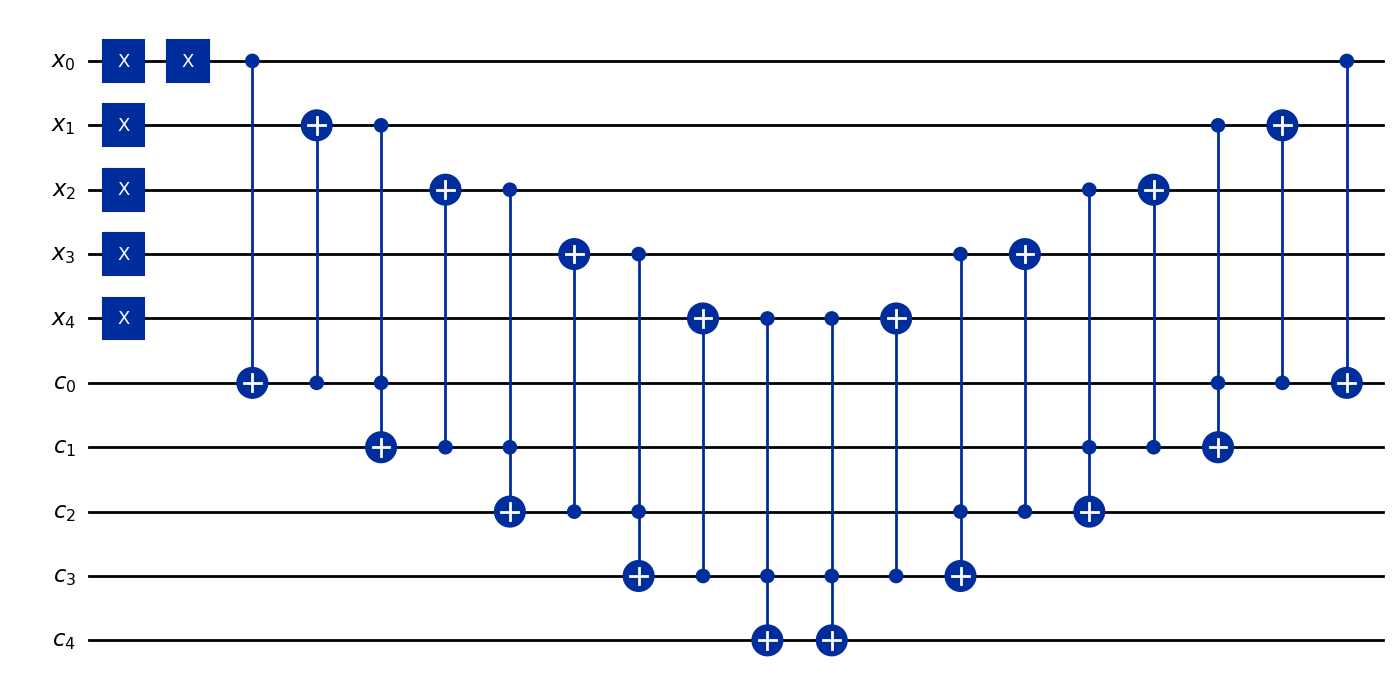

In [2]:
a = uneg_toffoli(5)
a.draw("mpl")

In [3]:
k = 6
a = 5  # represents 5/2^6

gate = uneg_toffoli(k).to_gate()

# circuit has 2k qubits: [x0..x5, c0..c5]
qc = QuantumCircuit(2*k)

# prepare |a> on x-register (little-endian: qubit 0 is LSB)
for i in range(k):
    if (a >> i) & 1:
        qc.x(i)

# apply Uneg on all 2k qubits
qc.append(gate, list(range(2*k)))

sv = Statevector.from_instruction(qc)
probs = sv.probabilities_dict()
bitstr = max(probs, key=probs.get)  # MSB->LSB string length 2k

# extract x-register bits: qubits 0..k-1 correspond to the LAST k characters in Qiskit's bitstring
x_bits_lsb_to_msb = bitstr[-k:][::-1]
a_out = int(x_bits_lsb_to_msb[::-1], 2)

print("x_out integer:", a_out, "expected:", 59)
print("x_out fraction:", a_out/(2**k), "expected:", 59/(2**k))

x_out integer: 59 expected: 59
x_out fraction: 0.921875 expected: 0.921875
